In [1]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import os
import pickle
import torch
import matplotlib.pyplot as plt
import cupy as cp
import cupyx as cpx
import time
import scprinter as scp
import warnings
from utils.utils import *
warnings.filterwarnings("ignore")


In [3]:
peak_mat_beta = sc.read_h5ad('integrate_h5ad/scATAC_beta_peak_intergtated_final_annoated.h5ad')

In [4]:
sample_map =  {
    "251030T": "P1",
    "251211T" : "P2",
    "251224T" : "P3",
    "260119T" : "P4",
    "260129T" : "P5"
}
peak_mat_beta.obs['donor'] = (
    peak_mat_beta.obs['sample_name']
    .map(sample_map)
    .fillna(peak_mat_beta.obs['sample_name'])
)

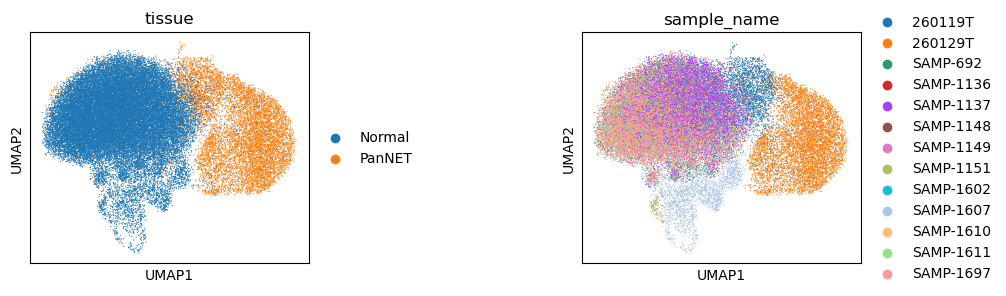

In [6]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(
        peak_mat_beta,
        color=['tissue','sample_name'],
        ncols=2,
        wspace=0.8,
        save='figures3_scATAC_UMAP',
    )

In [38]:
peak_mat_beta.obs['nFragments'] = peak_mat_beta.X.sum(axis=1)
peak_mat_beta.obs['nPeaks'] = (peak_mat_beta.X > 0).sum(axis=1)

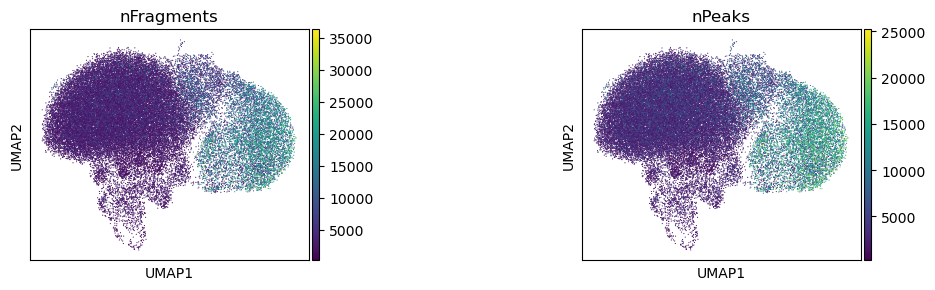

In [39]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(
        peak_mat_beta,
        color=['nFragments','nPeaks'],
        ncols=2,
        wspace=0.8
    )

In [7]:
scp.chromvar.sample_bg_peaks(peak_mat_beta,
                             genome=scp.genome.hg38,
                             method='chromvar',
                             niterations=2)

Fetching GC content:   0%|          | 0/231199 [00:00<?, ?it/s]

Sampling nearest neighbors
NNDescent (2500, 2)


Sampling background peaks:   0%|          | 0/2500 [00:00<?, ?it/s]

array([[  4474, 212798],
       [ 75943, 187972],
       [150053, 165095],
       ...,
       [ 44484,  53455],
       [208015, 101121],
       [122030,  65617]])

In [8]:
motif = scp.motifs.FigR_Human_Motifs(scp.genome.hg38,
                                     bg=list(peak_mat_beta.uns['bg_freq']),
                                     n_jobs=10,
                                     pvalue=5e-5, mode='motifmatchr')
motif.prep_scanner(
    None,
    pvalue=5e-5,
)
motif.chromvar_scan(peak_mat_beta)

  0%|          | 0/462398 [00:00<?, ?it/s]

In [10]:
import anndata as ad
import snapatac2 as snap
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
X = peak_mat_beta.varm['motif_match'].T
var = pd.DataFrame(index=peak_mat_beta.var_names)
obs = pd.DataFrame(
    index=pd.Index(
        peak_mat_beta.uns['motif_name'],
        name='TF'
    )
)
adata_motif = ad.AnnData(
    X=csr_matrix(X),
    obs=obs,
    var=var
)

In [12]:
adata_motif.write_h5ad('integrate_h5ad/scATAC_beta_peak_intergtated_motifmarch.h5ad',compression='gzip')

In [13]:
epi_chromevar_X = scp.chromvar.compute_deviations(peak_mat_beta, chunk_size=50000, device='cuda')
epi_chromevar_X.X = np.clip(epi_chromevar_X.X, -3, 3)

Computing expectation reads per cell and peak...


Processing TF chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Processing chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Processing background peaks:   0%|          | 0/2 [00:00<?, ?it/s]

In [15]:
epi_chromevar_X.obsm['X_umap'] = peak_mat_beta.obsm['X_umap']
epi_chromevar_X.obs['sample'] = peak_mat_beta.obs['sample']
epi_chromevar_X.obs['sample_name'] = peak_mat_beta.obs['sample_name']
epi_chromevar_X.obs['cell_type'] = peak_mat_beta.obs['cell_type']
epi_chromevar_X.obs['tissue'] = peak_mat_beta.obs['tissue']

In [18]:
epi_chromevar_X.write("integrate_h5ad/scATAC_beta_peak_intergtated_chromVAR.h5ad")

In [ ]:
epi_chromevar_X = sc.read_h5ad("integrate_h5ad/scATAC_beta_peak_intergtated_chromVAR.h5ad")

In [19]:
epi_chromevar_X.obs

,sample,sample_name,cell_type,tissue,donor
SAMP-1136:AAACGAAAGAGTCCGA-2,SAMP-1136_raw,SAMP-1136,Beta,Normal,SAMP-1136
SAMP-1136:AAACGAAAGGTTAACA-2,SAMP-1136_raw,SAMP-1136,Beta,Normal,SAMP-1136
SAMP-1136:AAACGAACAAGTCCTA-2,SAMP-1136_raw,SAMP-1136,Beta,Normal,SAMP-1136
SAMP-1136:AAACGAAGTGCACCCA-2,SAMP-1136_raw,SAMP-1136,Beta,Normal,SAMP-1136
SAMP-1136:AAACGAATCAGGCGCT-2,SAMP-1136_raw,SAMP-1136,Beta,Normal,SAMP-1136
...,...,...,...,...,...
SAMP-1137:TTTGTGTGTCTGTCCT-3,SAMP-1137_raw,SAMP-1137,Beta,Normal,SAMP-1137
SAMP-1137:TTTGTGTGTGGTCGAA-3,SAMP-1137_raw,SAMP-1137,Beta,Normal,SAMP-1137
SAMP-1137:TTTGTGTTCCACGCTT-3,SAMP-1137_raw,SAMP-1137,Beta,Normal,SAMP-1137
SAMP-1137:TTTGTGTTCCGGACTG-3,SAMP-1137_raw,SAMP-1137,Beta,Normal,SAMP-1137


In [20]:
sample_map =  {
    "251030T": "P1",
    "251211T" : "P2",
    "251224T" : "P3",
    "260119T" : "P4",
    "260129T" : "P5"
}
epi_chromevar_X.obs['donor'] = (
    epi_chromevar_X.obs['sample_name']
    .map(sample_map)
    .fillna(epi_chromevar_X.obs['sample_name'])
)

In [21]:
def pseudo_bulk_aggregation(adata, obs_key, agg_func="mean"):
    if obs_key not in adata.obs.columns:
        raise ValueError(f"'{obs_key}' not in adata.obs")

    unique_groups =  adata.obs[obs_key].unique().tolist()
    pseudo_bulk = []
    for group in tqdm(unique_groups):
        subset = adata[adata.obs[obs_key] == group]
        if agg_func == "sum":
            bulk_counts = subset.X.sum(axis=0)
        elif agg_func == "mean":
            bulk_counts = subset.X.mean(axis=0)
        else:
            raise ValueError("agg_func must be 'sum' or 'mean'")

        pseudo_bulk.append(bulk_counts)

    pseudo_bulk_arrary = np.array(pseudo_bulk).squeeze()
    pseudo_bulk_df = pd.DataFrame(pseudo_bulk_arrary.T, 
                                  index=adata.var_names, 
                                  columns=unique_groups)

    return pseudo_bulk_df

In [22]:
epi_chromevar_X

AnnData object with n_obs × n_vars = 45047 × 1141
    obs: 'sample', 'sample_name', 'cell_type', 'tissue', 'donor'
    obsm: 'X_umap'

In [41]:

TF_deviations_score = pseudo_bulk_aggregation(epi_chromevar_X,obs_key = 'tissue',agg_func="mean")
TF_deviations_score.to_csv('table/epi_TF_deviation_scores.csv')

100%|██████████| 2/2 [00:00<00:00,  8.59it/s]


In [42]:
TF_deviations_score

,Normal,PanNET
AC0235093,0.331137,-0.500003
AC1386961,-0.069865,0.106970
AHR,0.256148,-0.512726
AIRE,0.147624,-0.183721
ALX1,-0.203570,0.267194
...,...,...
ZSCAN4,-0.133363,0.207228
ZSCAN5,-0.180135,0.334589
ZSCAN5C,-0.261727,0.393376
ZSCAN9,-0.097296,0.115298


In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

adata = epi_chromevar_X

group_col = "tissue"  
groups = adata.obs[group_col].dropna().unique()

if len(groups) != 2:
    raise ValueError(f"{group_col} 必须正好有两个分组，但现在有: {groups}")

group1, group2 = groups[0], groups[1]

print("group1:", group1)
print("group2:", group2)

# -----------------------------
# 2. 提取 chromVAR matrix
# -----------------------------
X = adata.X

if sparse.issparse(X):
    X = X.toarray()

var_names = np.array(adata.var_names)

idx1 = adata.obs[group_col].values == group1
idx2 = adata.obs[group_col].values == group2

X1 = X[idx1, :]
X2 = X[idx2, :]

print(group1, X1.shape[0], "cells")
print(group2, X2.shape[0], "cells")

# -----------------------------
# 3. single-cell level t-test
# -----------------------------
t_stat, p_val = ttest_ind(
    X1,
    X2,
    axis=0,
    equal_var=False,   # Welch t-test
    nan_policy="omit"
)

# -----------------------------
# 4. 汇总结果
# -----------------------------
tf_ttest_res = pd.DataFrame({
    "TF": var_names,
    "group1": group1,
    "group2": group2,
    "mean_group1": np.nanmean(X1, axis=0),
    "mean_group2": np.nanmean(X2, axis=0),
    "diff_group2_minus_group1": np.nanmean(X2, axis=0) - np.nanmean(X1, axis=0),
    "t_statistic": t_stat,
    "pvalue": p_val,
    "n_cell_group1": X1.shape[0],
    "n_cell_group2": X2.shape[0]
})

# -----------------------------
# 5. FDR correction
# -----------------------------
valid = tf_ttest_res["pvalue"].notna()

tf_ttest_res.loc[valid, "FDR"] = multipletests(
    tf_ttest_res.loc[valid, "pvalue"],
    method="fdr_bh"
)[1]


group1: Normal
group2: PanNET
Normal 35990 cells
PanNET 9057 cells


,TF,group1,group2,mean_group1,mean_group2,diff_group2_minus_group1,t_statistic,pvalue,n_cell_group1,n_cell_group2,FDR
0,PHOX2B,Normal,PanNET,-0.182262,0.250104,0.432365,-17.526310,0.0,35990,9057,0.0
1,ZNF180,Normal,PanNET,0.276180,-0.503939,-0.780119,32.203178,0.0,35990,9057,0.0
2,ZNF182,Normal,PanNET,0.592250,-0.879082,-1.471332,59.417526,0.0,35990,9057,0.0
3,OTX2,Normal,PanNET,0.153612,-0.221881,-0.375494,15.444260,0.0,35990,9057,0.0
4,RARG,Normal,PanNET,0.213333,-0.342667,-0.556001,23.013432,0.0,35990,9057,0.0


In [45]:
tf_ttest_res = tf_ttest_res.sort_values("pvalue").reset_index(drop=True)
tf_ttest_res.to_csv('table/chrome_TF_ttest_results.csv', index=False)

# Visualization


In [7]:
import scanpy as sc
import matplotlib.pyplot as plt
import omicverse as ov

In [4]:
epi_chromevar_X = sc.read_h5ad("integrate_h5ad/scATAC_beta_peak_intergtated_chromVAR.h5ad")

In [5]:
normal_umap_tf = ["HNF1A", "HNF1B"]
pannet_umap_tf = ["FOS", "JUNB"]

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


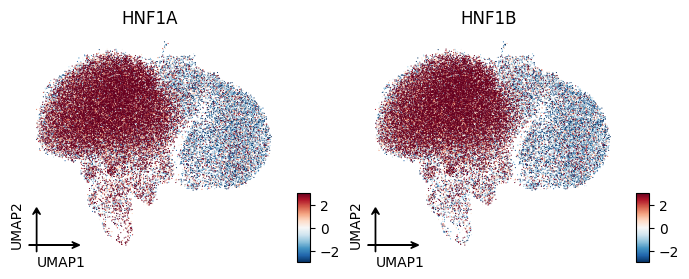

In [10]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    ov.pl.umap(epi_chromevar_X,color=normal_umap_tf,save = f'figures/Figure3_b_normal_TF_score.pdf')

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


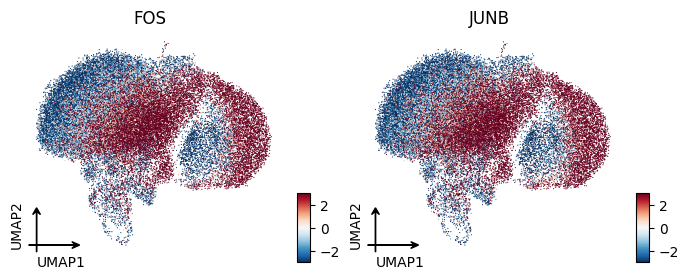

In [11]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    ov.pl.umap(epi_chromevar_X,color=pannet_umap_tf,save = f'figures/Figure3_c_pannet_TF_score.pdf')